In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
df = pd.read_csv("../data/steam_games_feature.csv")

df.head()


,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_log,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
0,Galactic Bowling,2008-10-21,0 - 20000,0,0,19.99,0,['English'],[],True,...,2.890372,-0.277778,3.044046,9.21044,0,Casual,Single-player,0,2000.0,0
1,Train Bandit,2017-10-12,0 - 20000,0,0,0.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,4.077537,0.813559,0.688135,9.21044,0,Action,Single-player,0,2010.0,0
2,Jolt Project,2021-11-17,0 - 20000,0,0,4.99,0,"['English', 'Portuguese - Brazil']",[],True,...,0.000000,0.000000,1.790091,9.21044,0,Action,Single-player,0,2020.0,1
3,Henosis™,2020-07-23,0 - 20000,0,0,5.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",[],True,...,1.386294,0.750000,1.944481,9.21044,0,Adventure,Single-player,0,2020.0,1
4,Two Weeks in Painland,2020-02-03,0 - 20000,0,0,0.00,0,"['English', 'Spanish - Spain']",[],True,...,4.077537,0.711864,0.000000,9.21044,1,Adventure,Single-player,0,2020.0,1


In [3]:
df.describe(include='all')

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Full audio languages,Windows,...,review_log,review_balance,price_log,owners_log,is_free,main_genre,main_category,rating_gap,release_decade,is_recent
count,82842,82842,82842,82842.000000,82842.000000,82842.000000,82842.000000,82842,82842,82842,...,82842.000000,82842.000000,82842.000000,82842.000000,82842.000000,82842,82842,82842.000000,82842.000000,82842.000000
unique,82842,4360,14,NaN,NaN,NaN,NaN,11098,2197,2,...,NaN,NaN,NaN,NaN,NaN,28,26,NaN,NaN,NaN
top,Galactic Bowling,2023-07-14,0 - 20000,NaN,NaN,NaN,NaN,['English'],[],True,...,NaN,NaN,NaN,NaN,NaN,Action,Single-player,NaN,NaN,NaN
freq,1,101,54046,NaN,NaN,NaN,NaN,42407,48145,82812,...,NaN,NaN,NaN,NaN,NaN,32510,74423,NaN,NaN,NaN
mean,NaN,NaN,NaN,133.873361,0.308237,7.199594,0.518095,NaN,NaN,NaN,...,2.722895,0.343337,1.560769,8.523601,0.192282,NaN,NaN,-3.319138,2015.934188,0.601869
std,NaN,NaN,NaN,5442.323951,2.237485,12.321096,13.080760,NaN,NaN,NaN,...,2.425379,0.405713,1.061971,3.450531,0.394096,NaN,NaN,15.545827,5.082524,0.489516
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,0.000000,-0.962963,0.000000,0.000000,0.000000,NaN,NaN,-97.000000,1990.000000,0.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.990000,0.000000,NaN,NaN,NaN,...,0.693147,0.000000,0.688135,9.210440,0.000000,NaN,NaN,0.000000,2010.000000,0.000000
50%,NaN,NaN,NaN,0.000000,0.000000,4.610000,0.000000,NaN,NaN,NaN,...,2.397895,0.395797,1.724551,9.210440,0.000000,NaN,NaN,0.000000,2020.000000,1.000000
75%,NaN,NaN,NaN,1.000000,0.000000,9.990000,0.000000,NaN,NaN,NaN,...,4.174387,0.703162,2.396986,9.210440,0.000000,NaN,NaN,0.000000,2020.000000,1.000000


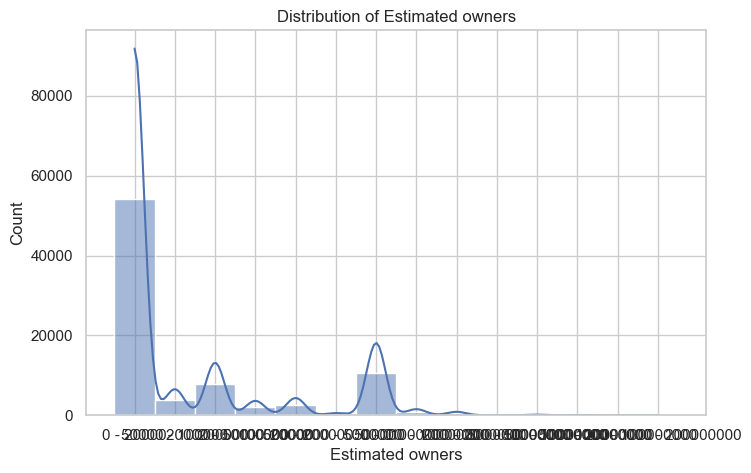

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated owners"], kde=True, bins=40)
plt.title("Distribution of Estimated owners")
plt.show()

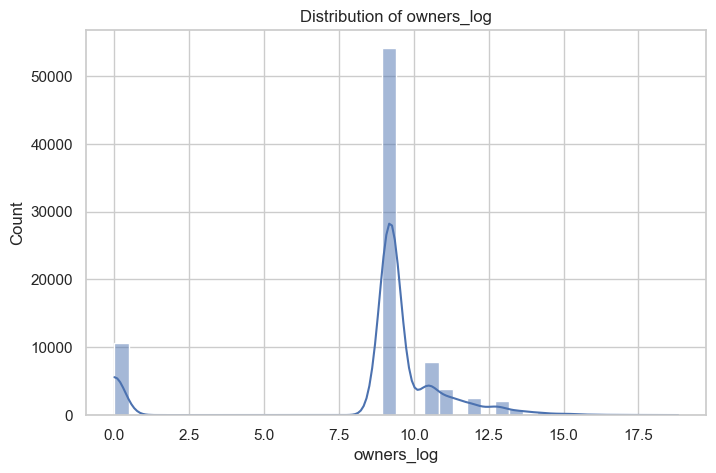

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["owners_log"], kde=True, bins=40)
plt.title("Distribution of owners_log")
plt.show()


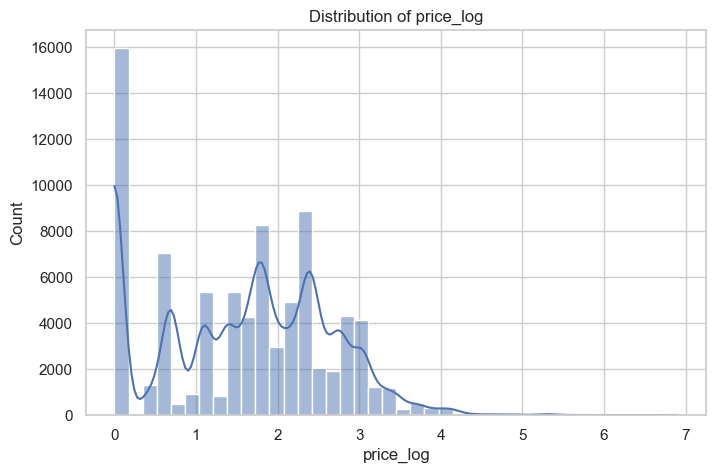

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["price_log"], kde=True, bins=40)
plt.title("Distribution of price_log")
plt.show()


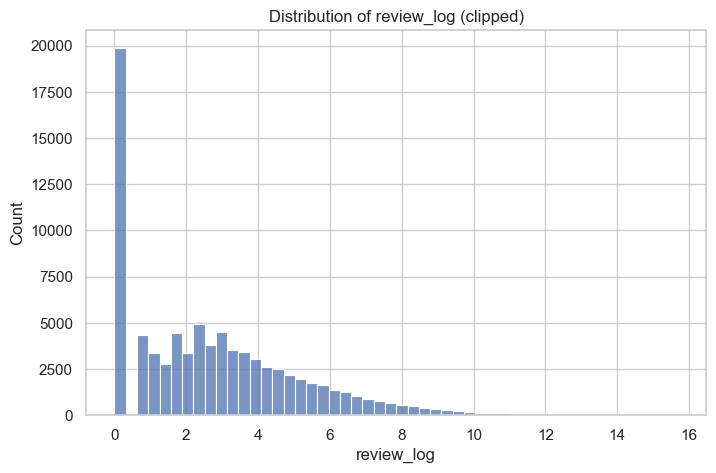

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["review_log"], kde=False, bins=50)
plt.title("Distribution of review_log (clipped)")
plt.show()


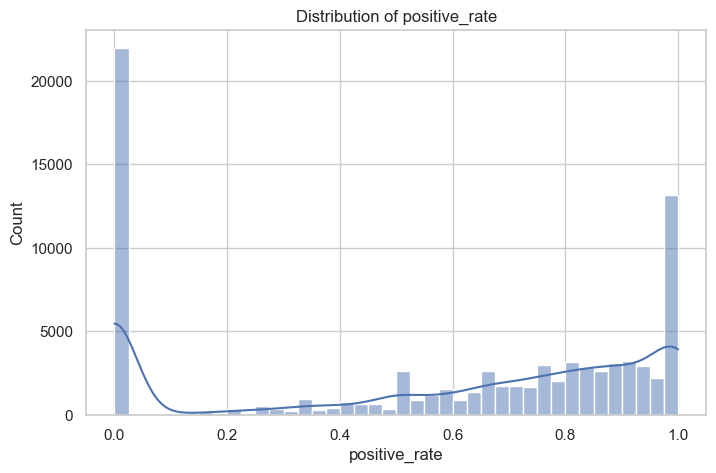

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["positive_rate"], kde=True, bins=40)
plt.title("Distribution of positive_rate")
plt.show()


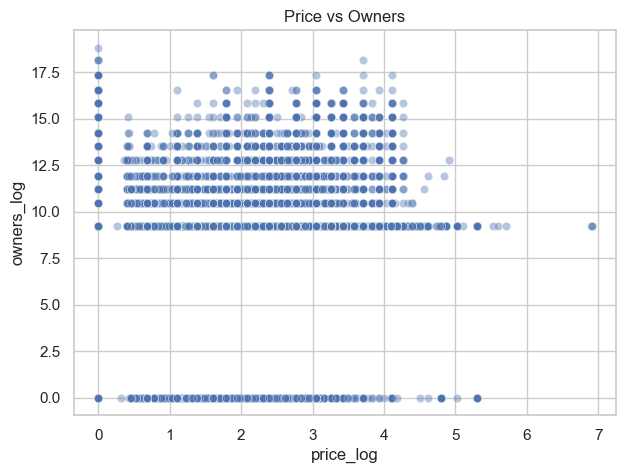

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="price_log", y="owners_log", data=df, alpha=0.4)
plt.title("Price vs Owners")
plt.show()


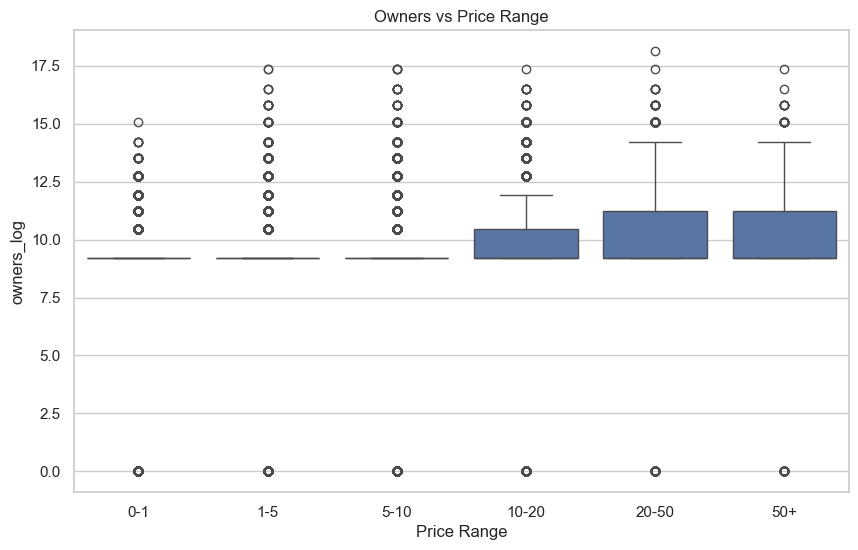

In [6]:
df["price_bin"] = pd.cut(df["Price"], bins=[0,1,5,10,20,50,200],
                         labels=["0-1","1-5","5-10","10-20","20-50","50+"])

plt.figure(figsize=(10,6))
sns.boxplot(x="price_bin", y="owners_log", data=df)
plt.title("Owners vs Price Range")
plt.xlabel("Price Range")
plt.ylabel("owners_log")
plt.show()


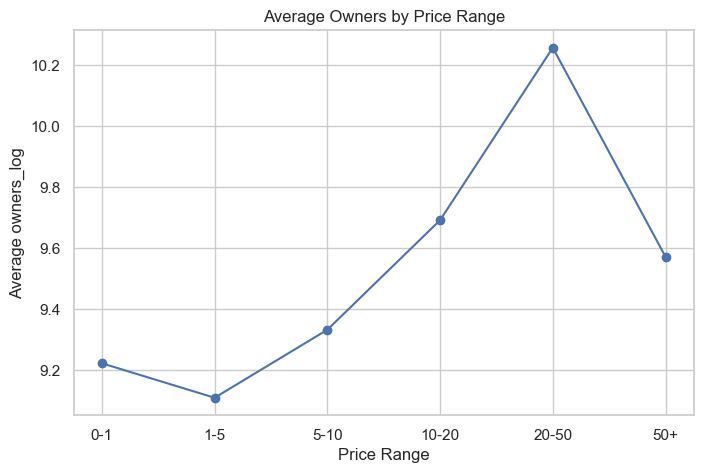

In [11]:
price_trend = df.groupby("price_bin")["owners_log"].mean()

price_trend.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Average Owners by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average owners_log")
plt.show()


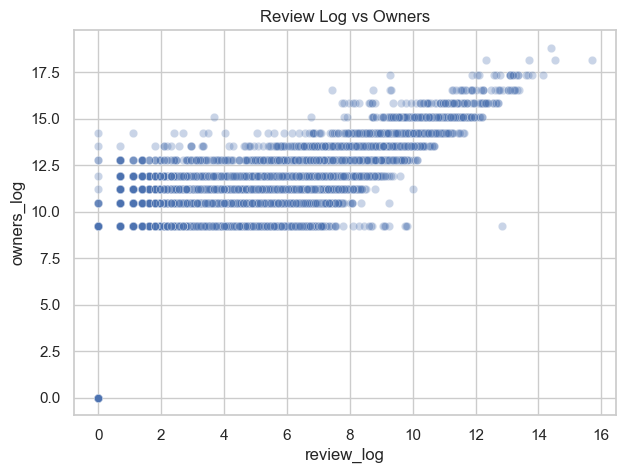

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="review_log", y="owners_log", data=df, alpha=0.3)
plt.title("Review Log vs Owners")
plt.show()


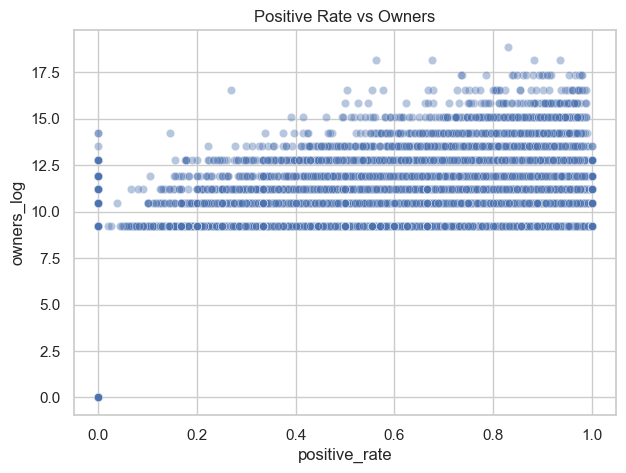

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="positive_rate", y="owners_log", data=df, alpha=0.4)
plt.title("Positive Rate vs Owners")
plt.show()


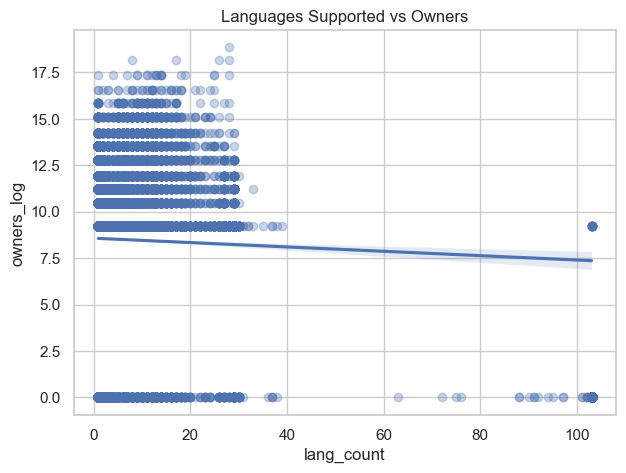

In [14]:
plt.figure(figsize=(7,5))
sns.regplot(x="lang_count", y="owners_log", data=df, scatter_kws={'alpha':0.3})
plt.title("Languages Supported vs Owners")
plt.show()


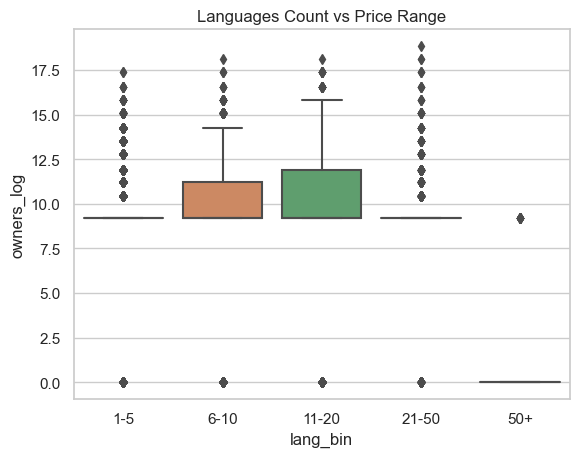

In [15]:
df["lang_bin"] = pd.cut(df["lang_count"], bins=[0,5,10,20,50,200],
                        labels=["1-5","6-10","11-20","21-50","50+"])

sns.boxplot(x="lang_bin", y="owners_log", data=df)

plt.title("Languages Count vs Price Range")
plt.xlabel("lang_bin")
plt.ylabel("owners_log")
plt.show()


<Axes: xlabel='lang_bin'>

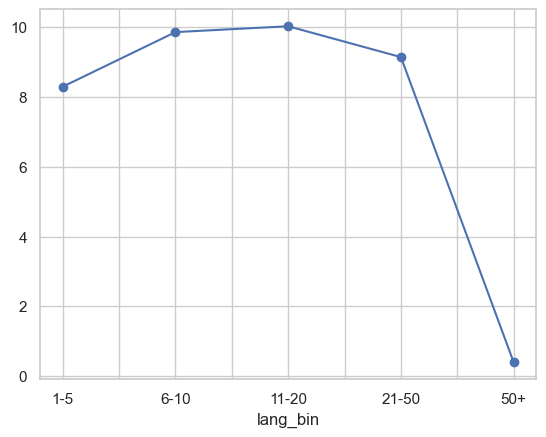

In [16]:
lang_trend = df.groupby("lang_bin")["owners_log"].mean()
lang_trend.plot(marker="o")


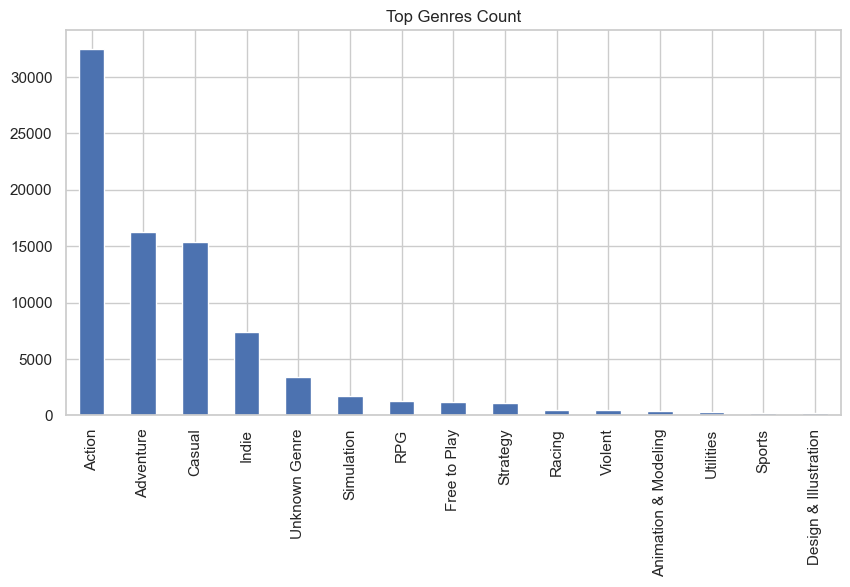

In [17]:
plt.figure(figsize=(10,5))
df["main_genre"].value_counts().head(15).plot(kind="bar")
plt.title("Top Genres Count")
plt.show()


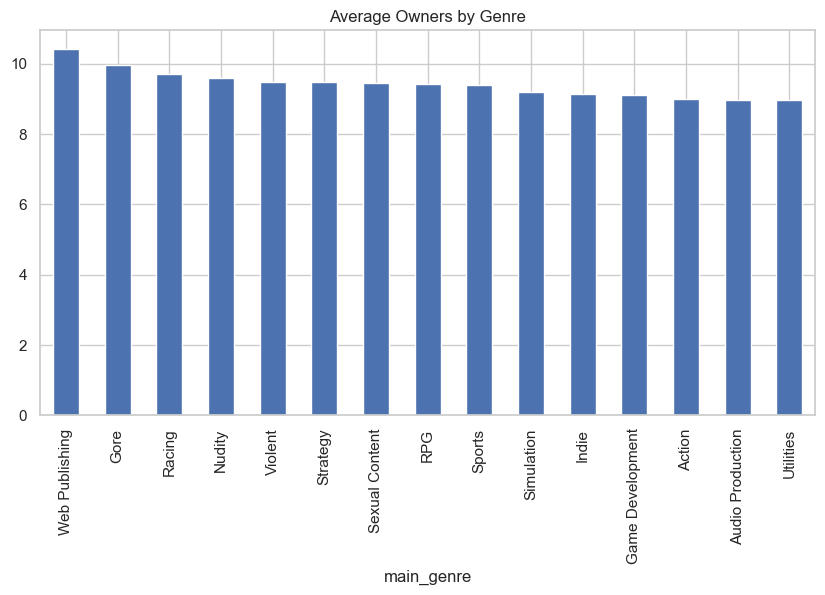

In [18]:
plt.figure(figsize=(10,5))
df.groupby("main_genre")["owners_log"].mean().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Average Owners by Genre")
plt.show()


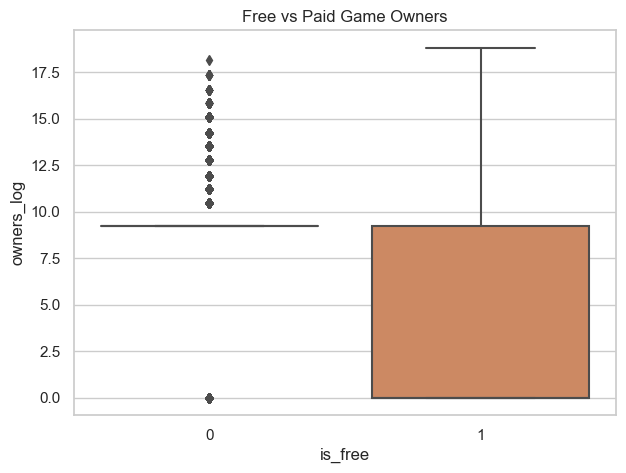

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["is_free"].astype(str), y=df["owners_log"])
plt.title("Free vs Paid Game Owners")
plt.show()


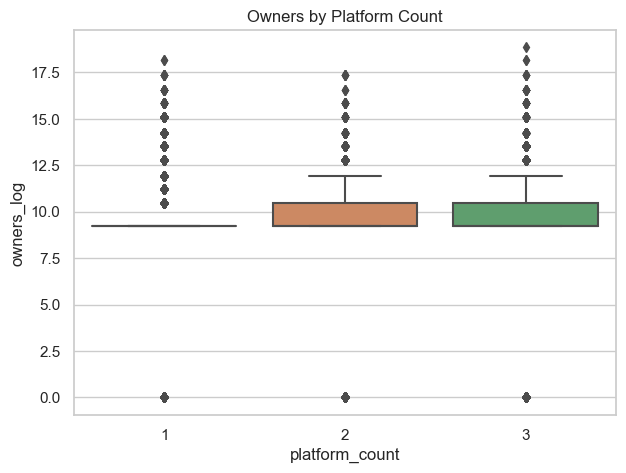

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x="platform_count", y="owners_log", data=df)
plt.title("Owners by Platform Count")
plt.show()


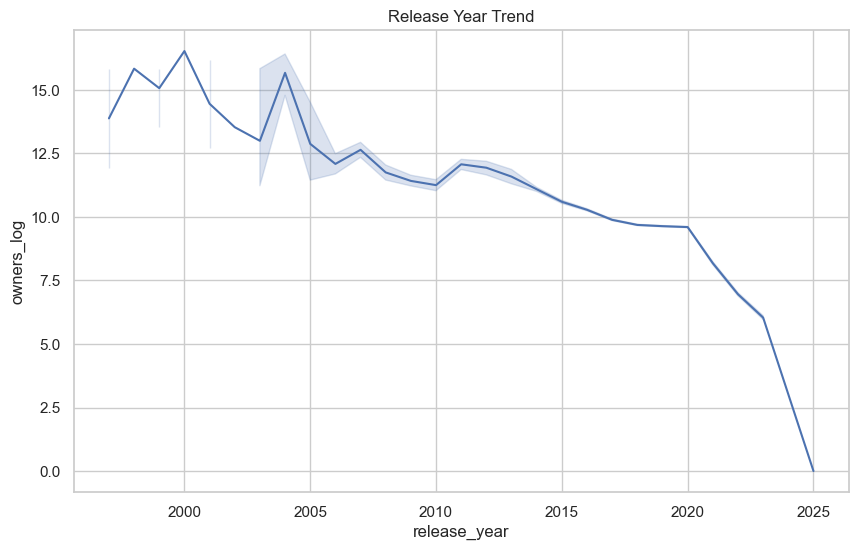

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(x="release_year", y="owners_log", data=df)
plt.title("Release Year Trend")
plt.show()


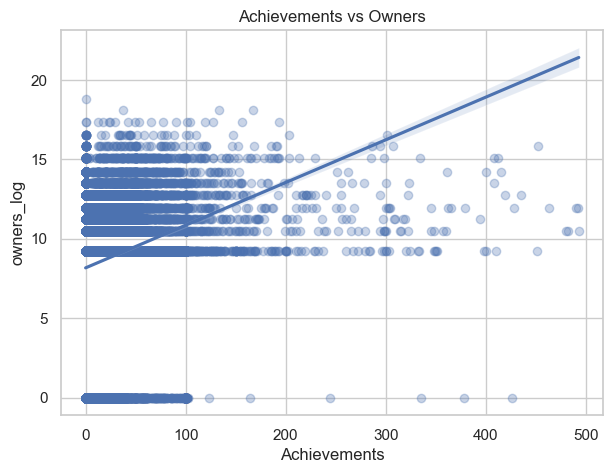

In [22]:

plt.figure(figsize=(7,5))
sns.regplot(x="Achievements", y="owners_log", data=df, scatter_kws={'alpha':0.3})
plt.title("Achievements vs Owners")
plt.show()


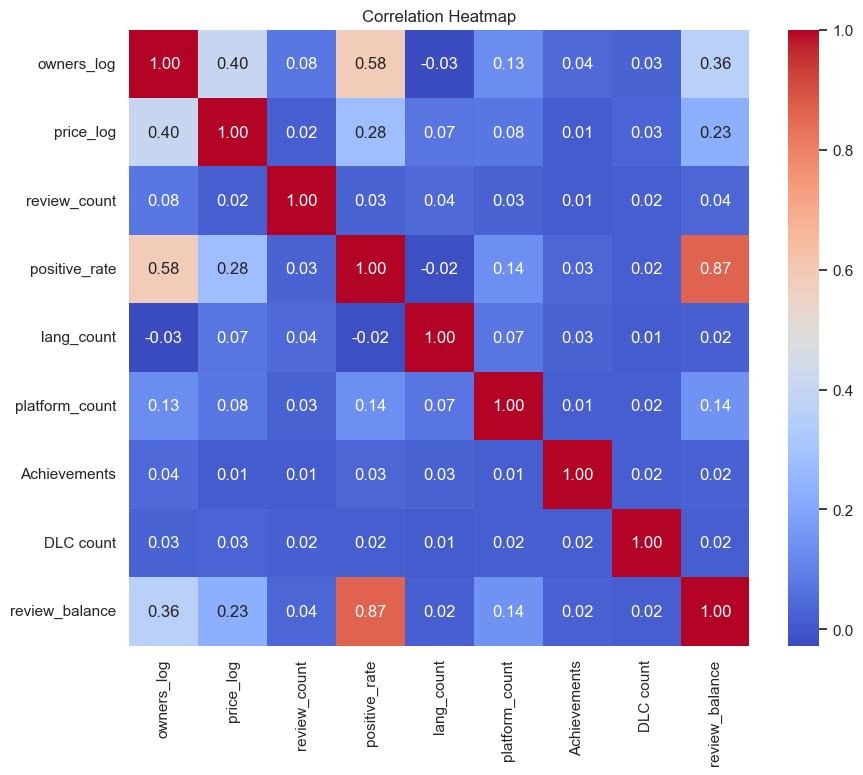

In [23]:
plt.figure(figsize=(10,8))
corr = df[["owners_log","price_log","review_count","positive_rate","lang_count",
           "platform_count","Achievements","DLC count","review_balance"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
# 建立一個函數來解析區間並計算中點
def parse_and_midpoint(range_str):
    if pd.isna(range_str):
        return np.nan
    try:
        range_str = str(range_str).replace(',', '')
        if ' - ' in range_str:
            lower, upper = map(float, range_str.split(' - '))
            return (lower + upper) / 2
        elif '+' in range_str:
            return float(range_str.replace('+', '')) * 1.5
        elif '-' in range_str:
            lower, upper = map(float, range_str.split('-'))
            return (lower + upper) / 2
        else:
            return float(range_str)
    except Exception:
        return np.nan

# 應用轉換並創建新的數值欄位
df['Estimated_owners_midpoint'] = df['Estimated owners'].apply(parse_and_midpoint)

# 執行 Log 轉換 (使用中點)
df['log_Estimated_owners_midpoint'] = np.log1p(df['Estimated_owners_midpoint'])

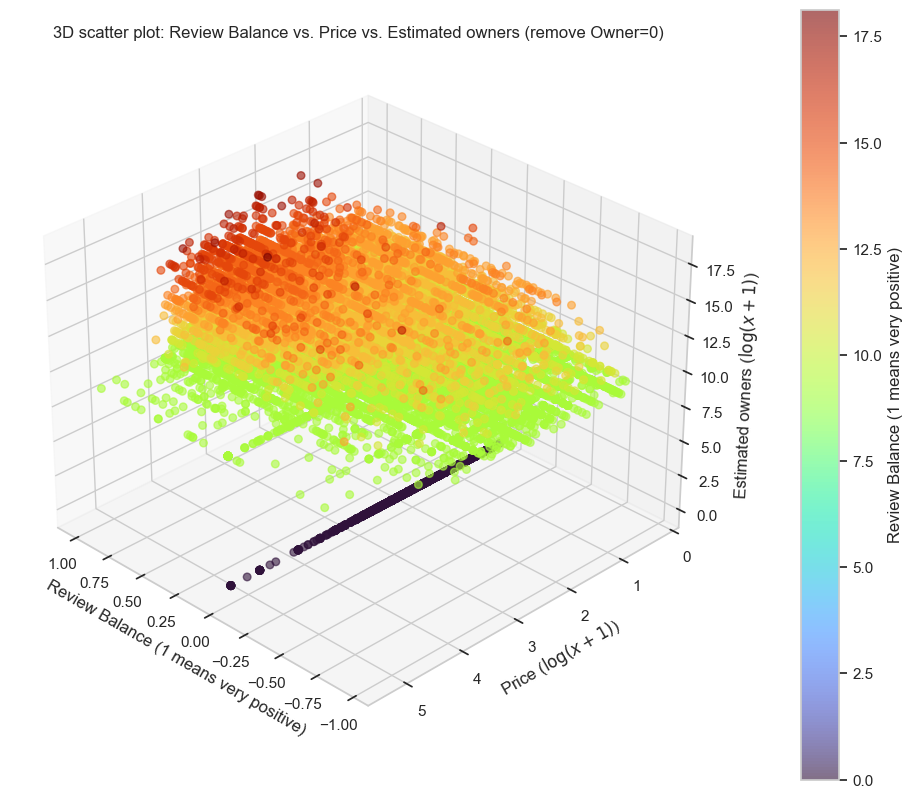

In [20]:
columns_for_3d = [
    'log_Estimated_owners_midpoint', 
    'price_log', 
    'review_balance', 
    'price_bin'
]

# 移除原始 NaN 值
df_clean = df.dropna(subset=columns_for_3d).copy()

# 更新繪圖所需的代碼
price_bin_codes_filtered = df_clean["price_bin"].cat.codes
labels = df_clean["price_bin"].cat.categories.tolist()

# --- 繪製 3D 圖 (使用 df_filtered) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    # X 軸：Review Balance 
    df_clean["review_balance"], 
    # Y 軸：價格
    df_clean["price_log"],
    # Z 軸：擁有者數量
    df_clean['log_Estimated_owners_midpoint'],
    
    # 顏色代表 log_Estimated_owners_midpoint
    c=df_clean["log_Estimated_owners_midpoint"],  
    cmap='turbo',
    s=30,
    alpha=0.6
)

# 調整視角 (使用您喜歡的視角)
ax.view_init(elev=30, azim=135)

# 更新標籤
ax.set_xlabel("Review Balance (1 means very positive)")
ax.set_ylabel("Price ($\log(x+1)$)")
ax.set_zlabel("Estimated owners ($\log(x+1)$)")
ax.set_title("3D scatter plot: Review Balance vs. Price vs. Estimated owners (remove Owner=0)")

# 添加顏色條
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Review Balance (1 means very positive)")

plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter # 引入動畫和儲存模組


# 1. 確保所有用於繪圖的欄位都存在
columns_for_3d = [
    'log_Estimated_owners_midpoint', 
    'price_log', 
    'review_balance', 
    'price_bin'
]

# 2. 移除原始 NaN 值
df_clean = df.dropna(subset=columns_for_3d).copy()


# --- 設定繪圖 ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    # X 軸：Review Balance 
    df_clean["review_balance"], 
    # Y 軸：價格
    df_clean["price_log"],
    # Z 軸：擁有者數量
    df_clean['log_Estimated_owners_midpoint'],
    
    # 顏色仍然代表 Z 軸：log_Estimated_owners_midpoint (讓高擁有者數的點更亮)
    c=df_clean["log_Estimated_owners_midpoint"], 
    cmap='turbo',
    s=30,
    alpha=0.6
)

# 設定標籤
ax.set_xlabel("Review Balance (1 means very positive)")
ax.set_ylabel("Price ($\log(x+1)$)")
ax.set_zlabel("Estimated owners ($\log(x+1)$)")
ax.set_title("3D Rotating: Review Balance vs. Price vs. Estimated owners")

# 添加顏色條 (這裡的顏色條標籤應反映顏色代表的變數，即 Estimated owners)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Estimated owners ($\log(x+1)$) (lighter the more owner)")

# --- 定義動畫更新函式 ---
def rotate(angle):
    # 使用 elev=20 作為仰角，只改變 azim (水平視角)
    ax.view_init(elev=20, azim=angle)
    return scatter,

# --- 創建動畫 ---
anim = FuncAnimation(
    fig, 
    rotate, 
    # frames=np.arange(0, 360, 5) 從 0 到 360 度，每 5 度一幀，共 72 幀
    frames=np.arange(0, 360, 5), 
    interval=60, # 每幀間隔 60 毫秒
    blit=False, 
    cache_frame_data=False
)

# --- 儲存為 GIF 檔案 ---
filename = 'rotating_3d_owner_price_balance.gif'
print(f"\n開始渲染動畫並儲存到 {filename}，請稍候...")

# 使用 PillowWriter 儲存 GIF 檔案
anim.save(
    filename, 
    writer=PillowWriter(fps=20), # fps=20 表示每秒播放 20 幀
    progress_callback=lambda i, n: print(f'進度: {i+1}/{n} 幀', end='\r')
)

print(f"\n 動畫已成功儲存到 {filename}。")

# 關閉圖形窗口
plt.close(fig)

原始資料點數量: 82836
移除 log(Owner) = 0 的點後，剩餘數量: 72179
共移除 10657 個點。

開始渲染動畫並儲存到 rotating_3d_owner_price_balance.gif，請稍候...


Font 'default' does not have a glyph for '\u984f' [U+984f], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u8272' [U+8272], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u8d8a' [U+8d8a], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u4eae' [U+4eae], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uff0c' [U+ff0c], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u6578' [U+6578], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u91cf' [U+91cf], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u9ad8' [U+9ad8], substituting with a dummy symbol.


進度: 72/72 幀
✅ 動畫已成功儲存到 rotating_3d_owner_price_balance.gif。


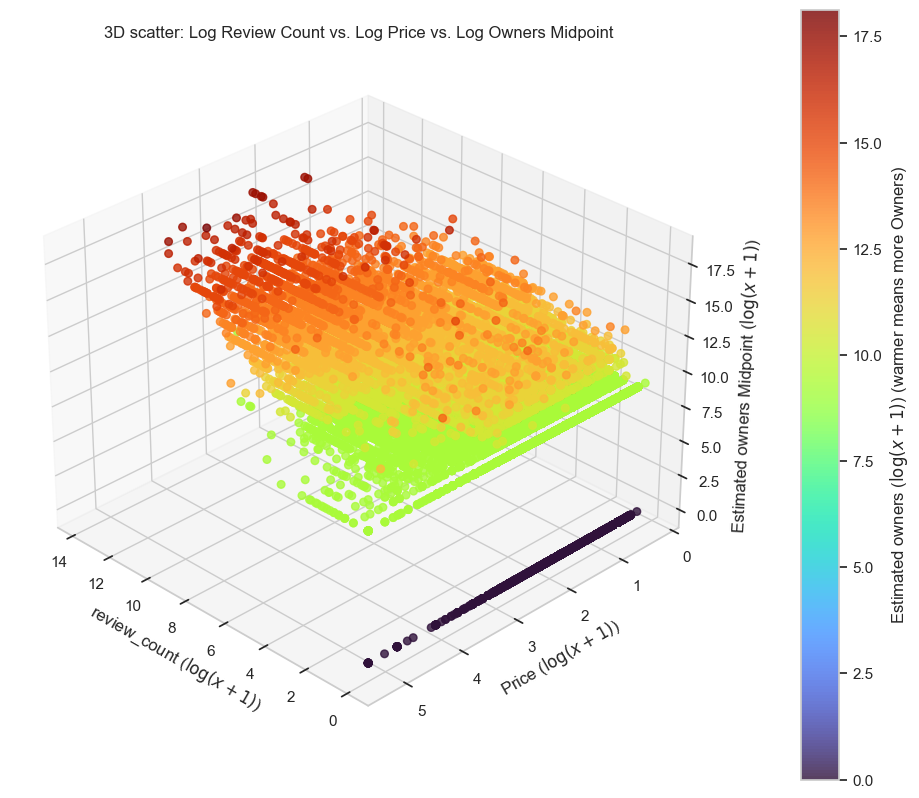

In [19]:
# --- 繪製 Log 轉換值圖 (靜態圖) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_clean['review_log'],
    df_clean["price_log"],
    df_clean["log_Estimated_owners_midpoint"], # Z 軸：Owners Log
    
    c=df_clean["log_Estimated_owners_midpoint"], 
    cmap='turbo',
    
    s=30,
    alpha=0.8
)

# 靜態視角設定
ax.view_init(elev=30, azim=135)

# 設定標籤
ax.set_xlabel("review_count ($\log(x+1)$)")
ax.set_ylabel("Price ($\log(x+1)$)")
ax.set_zlabel("Estimated owners Midpoint ($\\log(x+1)$)")

ax.set_title("3D scatter: Log Review Count vs. Log Price vs. Log Owners Midpoint")

# 添加顏色條 (顏色條現在代表 Owners Log 值)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Estimated owners ($\log(x+1)$) (warmer means more Owners)")

plt.show()

In [ ]:
# --- 繪製 Log 轉換值圖 (作為動畫的基礎) ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    # X 軸：Log Review Count
    df_clean['review_log'],
    # Y 軸：Log Price
    df_clean["price_log"],
    # Z 軸：Log Estimated owners (保持不變)
    df_clean["log_Estimated_owners_midpoint"],
    
    c=df_clean["log_Estimated_owners_midpoint"], 
    cmap='turbo', 
    s=30,
    alpha=0.8
)

# 設定標籤
ax.set_xlabel("review_count ($\log(x+1)$)")
ax.set_ylabel("Price ($\log(x+1)$)")
ax.set_zlabel("Estimated owners Midpoint ($\\log(x+1)$)")
ax.set_title("3D gif: Log Review Count vs. Log Price vs. Log Owners Midpoint ")

# 添加顏色條 (顏色條現在代表 Owners Log 值)
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Estimated owners ($\log(x+1)$) (warmer means more Owners)")


# --- 定義動畫更新函式 ---
def rotate(angle):
    # 改變水平視角 (azim)，elev (仰角) 保持不變
    ax.view_init(elev=20, azim=angle) 
    return scatter,

# --- 創建動畫 ---
anim = FuncAnimation(
    fig, 
    rotate, 
    frames=np.arange(0, 360, 5), # 每 5 度一幀
    interval=60, 
    blit=False, 
    cache_frame_data=False
)

# --- 儲存為 GIF 檔案 ---
filename = 'rotating_3d_owner_color_turbo.gif'
print(f"開始渲染動畫並儲存到 {filename}，請稍候...")

# PillowWriter 適用於 GIF 輸出
anim.save(
    filename, 
    writer=PillowWriter(fps=20),
    progress_callback=lambda i, n: print(f'進度: {i+1}/{n} 幀', end='\r')
)

print(f"\n動畫已成功儲存到 {filename}。") 

plt.close(fig)

開始渲染動畫並儲存到 rotating_3d_owner_color_turbo.gif，請稍候...
進度: 72/72 幀
✅ 動畫已成功儲存到 rotating_3d_owner_color_turbo.gif。


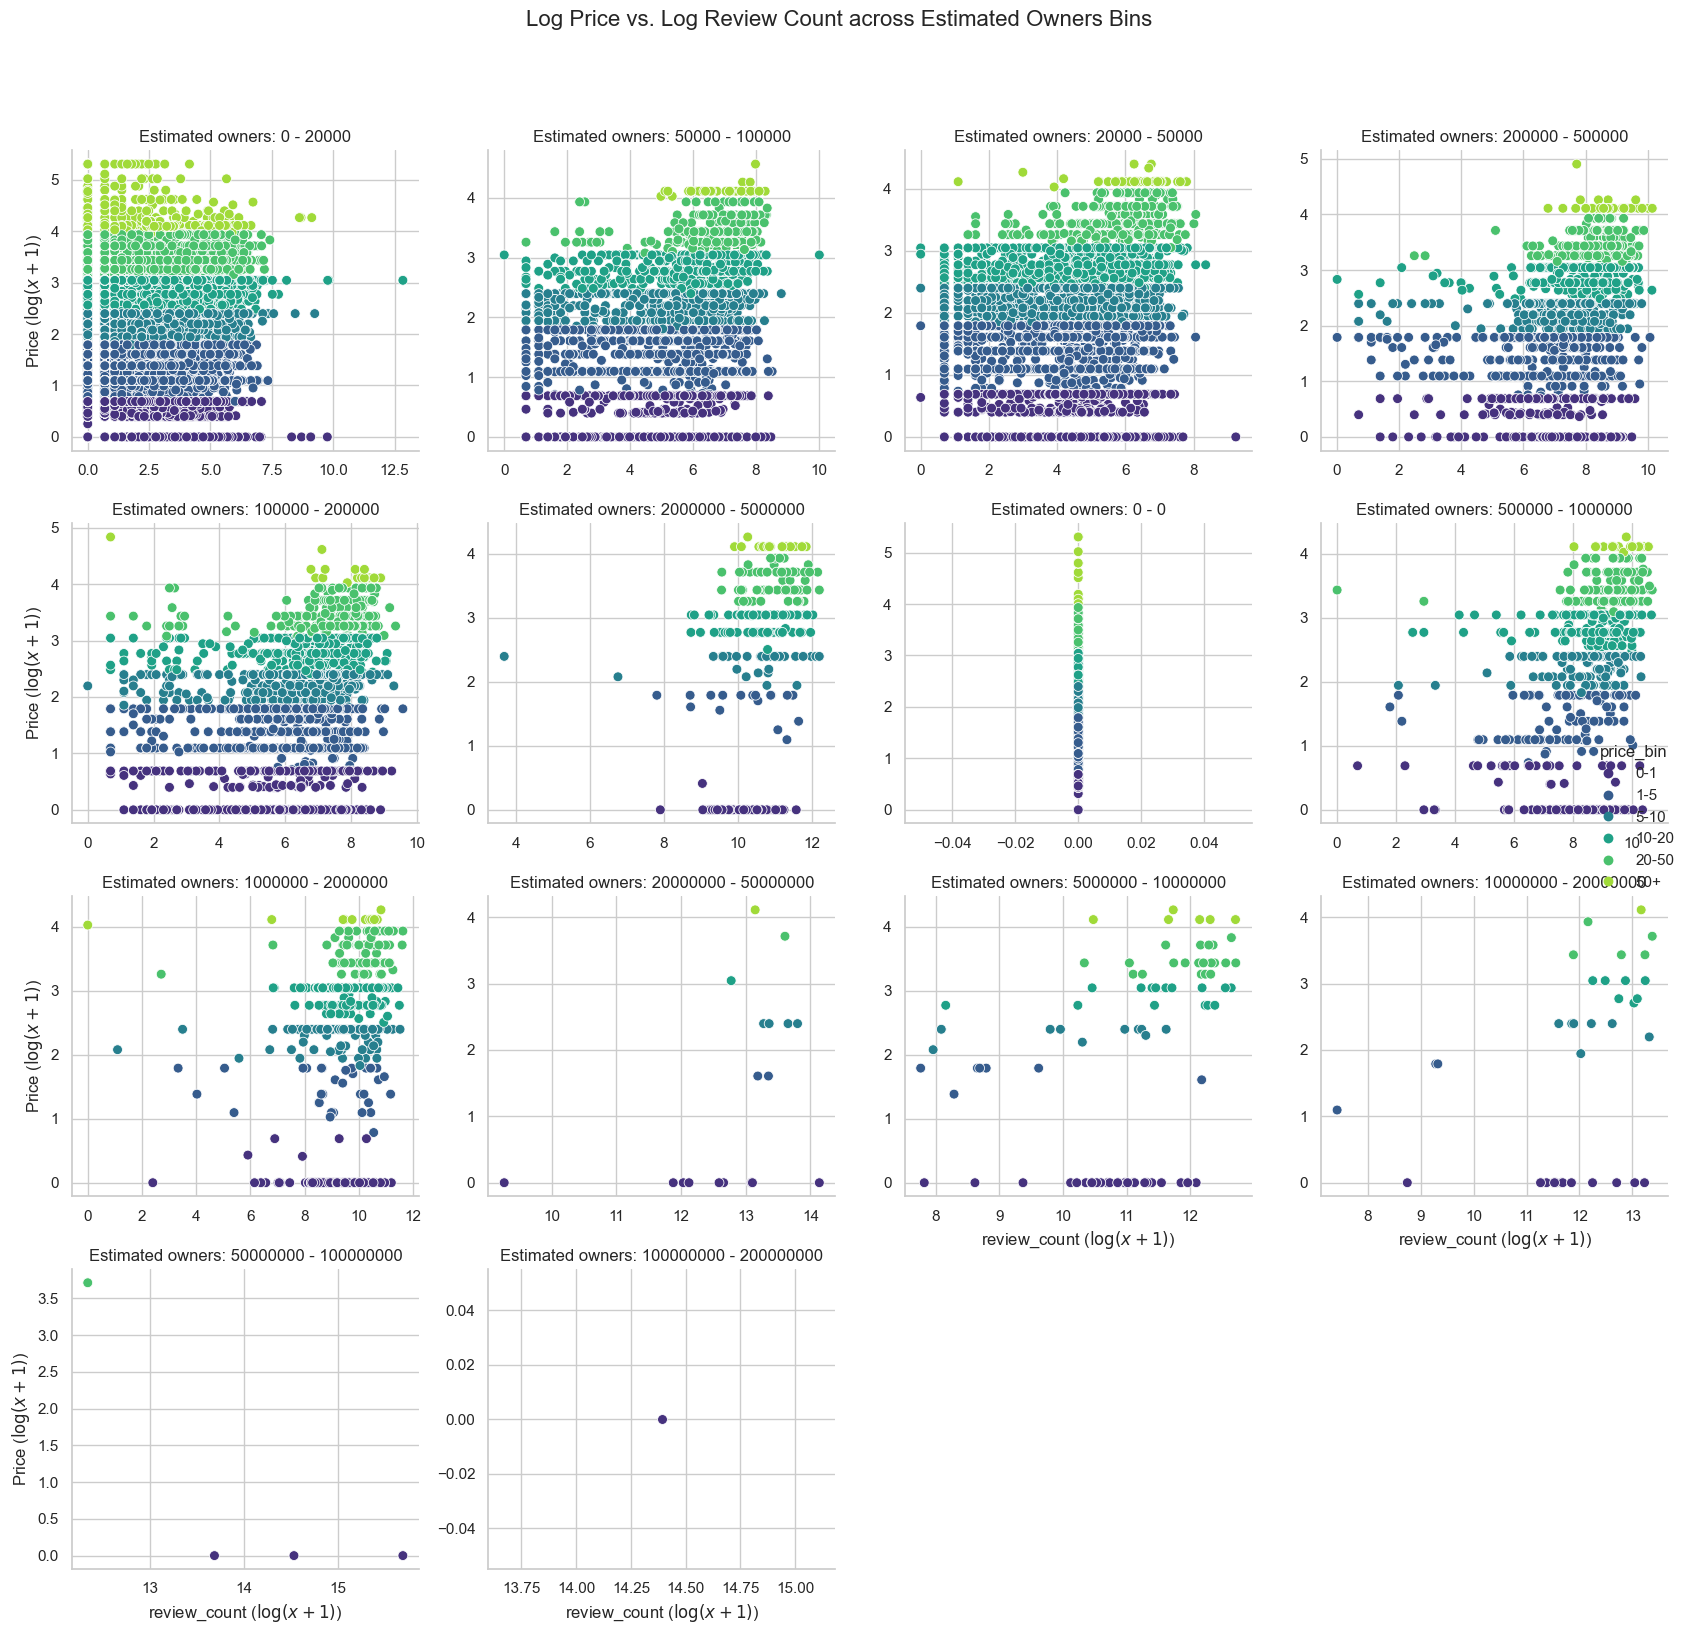

In [ ]:
# 使用 review_log 和 price_log 進行繪圖
g = sns.relplot(
    data=df.dropna(subset=['review_log', 'price_log', 'Estimated owners', 'price_bin']),
    x="review_log",
    y="price_log",
    hue="price_bin", # 用 price_bin 區分顏色
    col="Estimated owners", # 用 Estimated owners 區間作為子圖分割
    kind="scatter",
    palette='viridis',
    col_wrap=4, # 每行顯示 4 個子圖
    height=4,
    s=50,
    facet_kws={'sharex': False, 'sharey': False} # 允許每個子圖有獨立的軸範圍
)

# 設定軸標籤
g.set_axis_labels("review_count ($\log(x+1)$)", "Price ($\log(x+1)$)")
g.set_titles(col_template="Estimated owners: {col_name}")
plt.suptitle("Log Price vs. Log Review Count across Estimated Owners Bins", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()